In [1]:
from ultralytics import YOLO
import cv2
import os
import matplotlib.pyplot as plt
import yaml
from collections import defaultdict

In [ ]:
merged_dataset/
├── images/
│   ├── train/
│   │   ├── d1_image001.jpg
│   │   ├── d2_image001.jpg
│   ├── val/
│   ├── test/
├── labels/
│   ├── train/
│   │   ├── d1_image001.txt
│   │   ├── d2_image001.txt
├── data.yaml


In [ ]:


import os
import shutil
import yaml
from collections import Counter


dataset1_dir = "C:/Users/nandhudivya/Downloads/archive/Cars Detection"   
dataset2_dir = "C:/Users/nandhudivya/Downloads/car"   
merged_dir = "C:/Users/nandhudivya/Desktop/cv project"  
d1_tag = "d1"    
d2_tag = "d2"   
subsets = ["train", "val", "test"]
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def load_data_yaml(root):
    path = os.path.join(root, "data.yaml")
    if os.path.exists(path):
        with open(path, "r") as f:
            data = yaml.safe_load(f)
            names = data.get("names")
            return names
    return None

def list_images(folder):
    if not os.path.exists(folder): return []
    return [f for f in os.listdir(folder) if os.path.splitext(f.lower())[1] in image_exts]

def ensure_dirs():
    for s in subsets:
        os.makedirs(os.path.join(merged_dir, "images", s), exist_ok=True)
        os.makedirs(os.path.join(merged_dir, "labels", s), exist_ok=True)

def build_unified_names(names1, names2):
    if names1 and names2:
        unified = list(names1)
        for n in names2:
            if n not in unified:
                unified.append(n)
        
        map1 = {i: unified.index(names1[i]) for i in range(len(names1))}
        map2 = {i: unified.index(names2[i]) for i in range(len(names2))}
        return unified, map1, map2
    elif names1:
        unified = list(names1)
        map1 = {i: i for i in range(len(names1))}
        map2 = None  
        return unified, map1, map2
    elif names2:
        unified = list(names2)
        map1 = None
        map2 = {i: i for i in range(len(names2))}
        return unified, map1, map2
    else:
        return None, None, None  

def remap_label_lines(lines, mapping):
    """lines: list of strings from a .txt label file; mapping: dict old->new or None"""
    out_lines = []
    errors = []
    for ln in lines:
        ln = ln.strip()
        if ln == "":
            continue
        parts = ln.split()
        if len(parts) < 5:
            errors.append(f"bad_format: '{ln}'")
            continue
        try:
            cls = int(parts[0])
        except:
            errors.append(f"bad_class_id: '{parts[0]}' in '{ln}'")
            continue
        if mapping is not None:
            if cls not in mapping:
                errors.append(f"class_id_not_in_mapping: {cls}")
                continue
            cls = mapping[cls]
        try:
          
            rest = [f"{float(x):.6f}" for x in parts[1:5]]
        except:
            errors.append(f"bad_coords: '{ln}'")
            continue
        out_lines.append(" ".join([str(cls)] + rest))
    return out_lines, errors

def process_dataset(src_root, tag, mapping):
    stats = {"images_copied": 0, "labels_copied": 0, "empty_labels_created": 0, "errors": []}
    for s in subsets:
        img_folder = os.path.join(src_root, "images", s)
        lbl_folder = os.path.join(src_root, "labels", s)
        imgs = list_images(img_folder)
        for img_name in imgs:
            src_img_path = os.path.join(img_folder, img_name)
            
            new_base = f"{tag}_{img_name}"
            dst_img_path = os.path.join(merged_dir, "images", s, new_base)
            shutil.copy2(src_img_path, dst_img_path)
            stats["images_copied"] += 1

           
            base_no_ext = os.path.splitext(img_name)[0]
            src_label_name = base_no_ext + ".txt"
            src_label_path = os.path.join(lbl_folder, src_label_name)
            dst_label_path = os.path.join(merged_dir, "labels", s, os.path.splitext(new_base)[0] + ".txt")

            if os.path.exists(src_label_path):
                with open(src_label_path, "r") as f:
                    lines = f.readlines()
                out_lines, errors = remap_label_lines(lines, mapping)
                if errors:
                    stats["errors"].extend([f"{src_label_path}: {e}" for e in errors])
               
                with open(dst_label_path, "w") as f:
                    f.write("\n".join(out_lines))
                stats["labels_copied"] += 1
            else:
                
                open(dst_label_path, "w").close()
                stats["empty_labels_created"] += 1
    return stats

def write_merged_data_yaml(unified_names):
    data = {}
    data["train"] = os.path.abspath(os.path.join(merged_dir, "images", "train"))
    data["val"]   = os.path.abspath(os.path.join(merged_dir, "images", "val"))
   
    test_path = os.path.join(merged_dir, "images", "test")
    if os.path.exists(test_path) and len(os.listdir(test_path))>0:
        data["test"] = os.path.abspath(test_path)
    if unified_names is not None:
        data["nc"] = len(unified_names)
        data["names"] = unified_names
    else:
        
        max_id = -1
        for s in subsets:
            lbl_dir = os.path.join(merged_dir, "labels", s)
            if not os.path.exists(lbl_dir): continue
            for f in os.listdir(lbl_dir):
                if not f.endswith(".txt"): continue
                with open(os.path.join(lbl_dir,f),"r") as fh:
                    for ln in fh:
                        ln = ln.strip()
                        if not ln: continue
                        try:
                            cid = int(ln.split()[0])
                            if cid>max_id: max_id = cid
                        except:
                            pass
        if max_id >= 0:
            data["nc"] = max_id + 1
            data["names"] = [f"class_{i}" for i in range(data["nc"])]
        else:
            data["nc"] = 0
            data["names"] = []
    with open(os.path.join(merged_dir, "data.yaml"), "w") as f:
        yaml.safe_dump(data, f, sort_keys=False)
    return data

def summary_report():
    report = {}
    for s in subsets:
        img_count = len(os.listdir(os.path.join(merged_dir, "images", s))) if os.path.exists(os.path.join(merged_dir, "images", s)) else 0
        lbl_count = len(os.listdir(os.path.join(merged_dir, "labels", s))) if os.path.exists(os.path.join(merged_dir, "labels", s)) else 0
        report[s] = {"images": img_count, "labels": lbl_count}
   
    class_counter = Counter()
    for s in subsets:
        lbl_dir = os.path.join(merged_dir, "labels", s)
        if not os.path.exists(lbl_dir): continue
        for f in os.listdir(lbl_dir):
            if not f.endswith(".txt"): continue
            with open(os.path.join(lbl_dir,f),"r") as fh:
                for ln in fh:
                    parts = ln.strip().split()
                    if len(parts)<1: continue
                    try:
                        class_counter[int(parts[0])] += 1
                    except:
                        pass
    return report, class_counter

def main():
    print("1) Loading data.yaml from datasets (if present)...")
    names1 = load_data_yaml(dataset1_dir)
    names2 = load_data_yaml(dataset2_dir)
    print(" dataset1 names:", names1)
    print(" dataset2 names:", names2)

    print("\n2) Building unified class list and mapping...")
    unified_names, map1, map2 = build_unified_names(names1, names2)
    print(" unified names:", unified_names)
    print(" mapping dataset1:", map1)
    print(" mapping dataset2:", map2)
    if unified_names is None:
        print(" WARNING: no class names found in either data.yaml. The script will preserve numeric class IDs as-is.")
        print(" Make sure the numeric IDs mean the same classes in both datasets.")

    print("\n3) Preparing merged folders...")
    ensure_dirs()

    print("\n4) Processing dataset1...")
    stats1 = process_dataset(dataset1_dir, d1_tag, map1)
    print(" dataset1 stats:", stats1)

    print("\n5) Processing dataset2...")
    stats2 = process_dataset(dataset2_dir, d2_tag, map2)
    print(" dataset2 stats:", stats2)

    print("\n6) Writing merged data.yaml")
    merged_yaml = write_merged_data_yaml(unified_names)
    print(" merged data.yaml:", merged_yaml)

    print("\n7) Validation / summary")
    report, class_counter = summary_report()
    print(" per-split counts:", report)
    print(" class distribution (class_id:box_count):", dict(class_counter))

    print("\nDONE. Merged dataset created at:", os.path.abspath(merged_dir))
    print("You can now train with YOLOv8, for example:")
    print(f"  yolo detect train data={os.path.join(os.path.abspath(merged_dir),'data.yaml')} model=yolov8n.pt epochs=100 imgsz=640")

if __name__ == "__main__":
    main()


1) Loading data.yaml from datasets (if present)...
 dataset1 names: ['Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck']
 dataset2 names: ['Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100', 'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30', 'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70', 'Speed Limit 80', 'Speed Limit 90', 'Stop']

2) Building unified class list and mapping...
 unified names: ['Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck', 'Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100', 'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30', 'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70', 'Speed Limit 80', 'Speed Limit 90', 'Stop']
 mapping dataset1: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
 mapping dataset2: {0: 5, 1: 6, 2: 7, 3: 8, 4: 9, 5: 10, 6: 11, 7: 12, 8: 13, 9: 14, 10: 15, 11: 16, 12: 17, 13: 18, 14: 19}

3) Preparing merged folders...

4) Processing dataset1...
 data

Number of classes: 20

Total images in train split: 4408
Images per class:
  Ambulance: 118
  Bus: 136
  Car: 368
  Motorcycle: 126
  Truck: 130
  Green Light: 404
  Red Light: 435
  Speed Limit 10: 14
  Speed Limit 100: 263
  Speed Limit 110: 98
  Speed Limit 120: 242
  Speed Limit 20: 278
  Speed Limit 30: 331
  Speed Limit 40: 229
  Speed Limit 50: 266
  Speed Limit 60: 301
  Speed Limit 70: 313
  Speed Limit 80: 318
  Speed Limit 90: 167
  Stop: 285


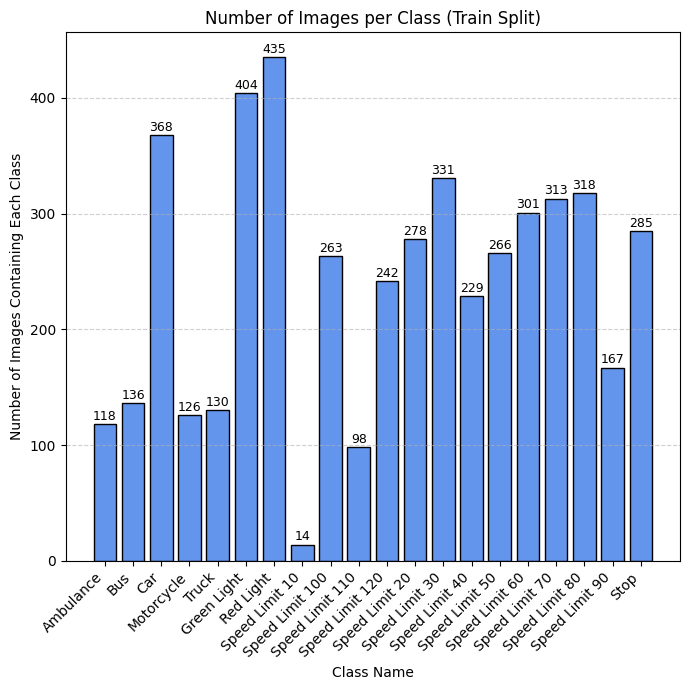

In [ ]:

merged_dir = "C:/Users/nandhudivya/Desktop/cv project"  
train_labels = os.path.join(merged_dir, "labels", "train")


data_yaml_path = os.path.join(merged_dir, "data.yaml")
with open(data_yaml_path, "r") as f:
    data = yaml.safe_load(f)

class_names = data.get("names", [])
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")


class_to_images = defaultdict(set)

for file in os.listdir(train_labels):
    if not file.endswith(".txt"):
        continue
    image_name = os.path.splitext(file)[0]
    with open(os.path.join(train_labels, file), "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                try:
                    cls = int(parts[0])
                    class_to_images[cls].add(image_name)
                except ValueError:
                    pass


classes = sorted(class_to_images.keys())
counts = [len(class_to_images[cid]) for cid in classes]
labels = [class_names[cid] if cid < len(class_names) else f"class_{cid}" for cid in classes]

total_images = len(os.listdir(os.path.join(merged_dir, "images", "train")))
print(f"\nTotal images in train split: {total_images}")
print("Images per class:")
for label, count in zip(labels, counts):
    print(f"  {label}: {count}")


plt.figure(figsize=(7, 7))
bars = plt.bar(labels, counts, color="cornflowerblue", edgecolor="black")


for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(count),
             ha='center', va='bottom', fontsize=9)

plt.title("Number of Images per Class (Train Split)")
plt.xlabel("Class Name")
plt.ylabel("Number of Images Containing Each Class")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:

model = YOLO("yolov8n.pt")

Model Training:

In [ ]:

model.train(
    data="C:/Users/nandhudivya/Desktop/cv project/data.yaml",  
    epochs=100,                  
    imgsz=640,                  
    batch=8                 
)

New https://pypi.org/project/ultralytics/8.3.209 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.205  Python-3.10.18 torch-2.1.0 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/nandhudivya/Desktop/cv project/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, nam

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000012AAC9576A0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043

In [ ]:
model = YOLO("C:/Users/nandhudivya/runs/detect/train2/weights/best.pt")  

metrics = model.val(
    data="C:/Users/nandhudivya/Desktop/cv project/data.yaml",  
    imgsz=640,                 
    conf=0.2522222
)


Ultralytics 8.3.205  Python-3.10.18 torch-2.1.0 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 72 layers, 3,009,548 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 479.3195.6 MB/s, size: 20.4 KB)
val: Scanning C:\Users\nandhudivya\Desktop\cv project\labels\val.cache... 1051 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1051/1051  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 66/66 8.9it/s 7.4s<0.2s
                   all       1051       1398      0.865      0.829      0.867       0.75
             Ambulance         50         64      0.725      0.812      0.854      0.715
                   Bus         30         46      0.726      0.652      0.753      0.633
                   Car         90        238      0.611      0.363      0.476      0.382
            Motorcycle         42         46       0.62      0.652      0.595      0.353
               

In [5]:
print(f"mAP@0.5: {metrics.box.map50:.3f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.3f}")
print(f"Mean Precision: {metrics.box.mp:.3f}")
print(f"Mean Recall: {metrics.box.mr:.3f}")

mAP@0.5: 0.867
mAP@0.5:0.95: 0.750
Mean Precision: 0.865
Mean Recall: 0.829


In [ ]:
results = model.val()
print(results)  

Ultralytics 8.3.205  Python-3.10.18 torch-2.1.0 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 316.5202.9 MB/s, size: 15.2 KB)
val: Scanning C:\Users\nandhudivya\Desktop\cv project\labels\val.cache... 1051 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1051/1051  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 66/66 9.1it/s 7.2s<0.2s
                   all       1051       1398      0.865      0.829      0.864      0.723
             Ambulance         50         64      0.725      0.812      0.854      0.695
                   Bus         30         46      0.726      0.652      0.692      0.561
                   Car         90        238      0.611      0.363       0.42      0.306
            Motorcycle         42         46       0.62      0.652      0.583      0.321
                 Truck         38         60      0.622      0.367       0.39      0.259
      

#test with image
# Automated way (YOLO)
#Let YOLO handle everything with one call to model.predict().
#YOLO automatically loads images, runs predictions, draws bounding boxes, and saves results to a folder.
#Minimal code.

#Pros:
#Very fast to run.
#Minimal code required.
#Easy to use for quick testing.

#Cons:
#Less control over style and extra processing.
#Less flexibility.

In [ ]:


from ultralytics import YOLO

model = YOLO("C:/Users/nandhudivya/runs/detect/train2/weights/best.pt")

results = model.predict(
    source= "C:/Users/nandhudivya/Desktop/cv project/images/test",  
    conf=0.25,  
    save=True
)



image 1/764 C:\Users\nandhudivya\Desktop\cv project\images\test\d1_00dea1edf14f09ab_jpg.rf.3f17c8790a68659d03b1939a59ccda80.jpg: 640x640 1 Ambulance, 26.8ms
image 2/764 C:\Users\nandhudivya\Desktop\cv project\images\test\d1_00dea1edf14f09ab_jpg.rf.KJ730oDTFPdXdJxvSLnX.jpg: 640x640 1 Ambulance, 27.2ms
image 3/764 C:\Users\nandhudivya\Desktop\cv project\images\test\d1_00e481ea1a520175_jpg.rf.6e6a8b3b45c9a11d106958f88ff714ea.jpg: 640x640 4 Buss, 24.2ms
image 4/764 C:\Users\nandhudivya\Desktop\cv project\images\test\d1_00e481ea1a520175_jpg.rf.MV6sZ8QCFwFeMYaI2tHm.jpg: 640x640 4 Buss, 24.6ms
image 5/764 C:\Users\nandhudivya\Desktop\cv project\images\test\d1_08c8b73e0c2e296e_jpg.rf.7IkYAamjZhnwsoXSrwKt.jpg: 640x640 2 Buss, 24.5ms
image 6/764 C:\Users\nandhudivya\Desktop\cv project\images\test\d1_08c8b73e0c2e296e_jpg.rf.effa65856584463c08848031cab357b9.jpg: 640x640 2 Buss, 24.4ms
image 7/764 C:\Users\nandhudivya\Desktop\cv project\images\test\d1_10c26c6598677a1f_jpg.rf.USCbBYVcUICkLhuq07Lw.j

#test with video
# Automated way (YOLO)
#Let YOLO handle everything with one call to model.predict().
#YOLO automatically loads images, runs predictions, draws bounding boxes, and saves results to a folder.
#Minimal code.

#Pros:
#Very fast to run.
#Minimal code required.
#Easy to use for quick testing.

#Cons:
#Less control over style and extra processing.
#Less flexibility.

In [ ]:



model = YOLO("C:/Users/nandhudivya/runs/detect/train2/weights/best.pt")

results = model.predict(
    source= "C:/Users/nandhudivya/Desktop/cv project - video/test video/test.mp4",  
    conf=0.25,  
    save=True
)




WARNING 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/3934) C:\Users\nandhudivya\Desktop\cv project - video\test video\test.mp4: 384x640 4 Cars, 1 Truck, 476.7ms
video 1/1 (frame 2/3934) C:\Users\nandhudivya\Desktop\cv project - video\test video\test.mp4: 384x640 4 Cars, 39.7ms
video 1/1 (frame 3/3934) C:\Users\nandhudivya\Desktop\cv project - video\test video\test.mp4: 384x640 4 Cars, 1 Green Light, 35.4ms
video 1/1 (frame 4/3934) C:\Users\nandhudivya\Desktop\cv project - video\test video

# Manual way (OpenCV)

#Load each test image yourself.
#Use model.predict() for each image.
#Manually draw bounding boxes and labels with OpenCV (cv2.rectangle, cv2.putText).
#Control resizing, colors, text style, etc.

#Pros:
#Full control of visualization and processing.
#Flexible for custom logic.

#Cons:
#More code to write.
#More complexity.

In [ ]:

    
test_folder = "C:/Users/nandhudivya/Desktop/cv project/images/test"
resize_width = 640
resize_height = 640

for filename in os.listdir(test_folder):
    if filename.endswith((".jpg", ".png", ".jpeg")):
        image_path = os.path.join(test_folder, filename)

        results = model.predict(source=image_path, imgsz=640, conf=0.25)

        img = cv2.imread(image_path)
        img = cv2.resize(img, (resize_width, resize_height))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        for result in results[0].boxes.data.tolist():
            x1, y1, x2, y2, score, class_id = result
            label = results[0].names[int(class_id)]
            cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
            cv2.putText(img, f"{label} {score:.2f}", (int(x1), int(y1) - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

            Show the image with detections
            plt.figure(figsize=(8, 8))
            plt.imshow(img)
            plt.axis("off")
            plt.title(filename)
            plt.show()


image 1/1 C:\Users\nandhudivya\Desktop\cv project\images\test\d1_00dea1edf14f09ab_jpg.rf.3f17c8790a68659d03b1939a59ccda80.jpg: 640x640 1 Ambulance, 28.6ms
Speed: 16.0ms preprocess, 28.6ms inference, 18.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\nandhudivya\Desktop\cv project\images\test\d1_00dea1edf14f09ab_jpg.rf.KJ730oDTFPdXdJxvSLnX.jpg: 640x640 1 Ambulance, 32.0ms
Speed: 14.0ms preprocess, 32.0ms inference, 5.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\nandhudivya\Desktop\cv project\images\test\d1_00e481ea1a520175_jpg.rf.6e6a8b3b45c9a11d106958f88ff714ea.jpg: 640x640 3 Buss, 28.8ms
Speed: 13.2ms preprocess, 28.8ms inference, 8.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\nandhudivya\Desktop\cv project\images\test\d1_00e481ea1a520175_jpg.rf.MV6sZ8QCFwFeMYaI2tHm.jpg: 640x640 3 Buss, 34.5ms
Speed: 13.2ms preprocess, 34.5ms inference, 6.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Use